# Nsight Compute Structured Review

This notebook reads the SQLite-first analysis bundle generated by `scripts/analyze_ncu_run.py`.
It focuses on the structured core section imports rather than string-hit heuristics so we can review one `ncu` run in a way that is much closer to the Nsight Compute UI.


In [17]:
from pathlib import Path

RUN_ID = "20260319-1514-train-completion-01"
WORKING_DIR = Path.cwd().resolve()
REPO_ROOT = next(
    (
        path
        for path in [WORKING_DIR, *WORKING_DIR.parents]
        if (path / "profiling").exists() and (path / "artifacts").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the Griffin repo root from the current working directory.")

ANALYSIS_DIR = REPO_ROOT / "artifacts" / "profiles" / "analysis" / RUN_ID
DB_PATH = ANALYSIS_DIR / "ncu_analysis.sqlite"


In [18]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from textwrap import dedent

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DB_PATH}. Open this notebook from the Griffin repo or rerun the setup cell so REPO_ROOT resolves correctly."
    )

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_rows", 60)
pd.set_option("display.float_format", lambda value: f"{value:0.3f}")

conn = sqlite3.connect(DB_PATH)
SUCCESS_STATUSES = {"success", "cached_success"}

def q(sql: str, params=None) -> pd.DataFrame:
    return pd.read_sql_query(sql, conn, params=params or [])

def display_md(text: str) -> None:
    display(Markdown(dedent(text).strip()))

def metric_summaries(section_ids) -> pd.DataFrame:
    placeholders = ", ".join(["?"] * len(section_ids))
    sql = f"""
        SELECT
            section_id,
            metric_name,
            metric_unit,
            value_count,
            ROUND(min_value, 3) AS min_value,
            ROUND(avg_value, 3) AS avg_value,
            ROUND(max_value, 3) AS max_value
        FROM numeric_metric_summaries
        WHERE section_id IN ({placeholders})
        ORDER BY section_id, metric_name
    """
    return q(sql, section_ids)

def metric_value(summary_df: pd.DataFrame, section_id: str, metric_name: str) -> float:
    match = summary_df[
        (summary_df["section_id"] == section_id) & (summary_df["metric_name"] == metric_name)
    ]
    if match.empty:
        return np.nan
    return float(match.iloc[0]["avg_value"])

def sampled_metrics(pairs) -> pd.DataFrame:
    if not pairs:
        return pd.DataFrame(
            columns=[
                "sample_rank",
                "launch_id",
                "section_id",
                "metric_name",
                "metric_unit",
                "metric_value_num",
            ]
        )
    clauses = " OR ".join(["(section_id = ? AND metric_name = ?)"] * len(pairs))
    params = [item for pair in pairs for item in pair]
    sql = f"""
        SELECT
            sample_rank,
            launch_id,
            section_id,
            metric_name,
            metric_unit,
            metric_value_num
        FROM sampled_section_metric_values
        WHERE metric_value_num IS NOT NULL
          AND ({clauses})
        ORDER BY sample_rank, section_id, metric_name
    """
    return q(sql, params)

def sampled_summary(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    summary = (
        df.groupby(["section_id", "metric_name", "metric_unit"], dropna=False)["metric_value_num"]
        .agg(samples="size", min_value="min", median_value="median", avg_value="mean", max_value="max")
        .reset_index()
    )
    return summary.round(3)

def plot_bar(ax, data: pd.Series, title: str, ylabel: str, color: str = "#4C72B0") -> None:
    data.plot.bar(ax=ax, legend=False, color=color)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

def pct(value: float) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{value:0.2f}%"

def num(value: float, digits: int = 3) -> str:
    if pd.isna(value):
        return "n/a"
    return f"{value:0.{digits}f}"


def summary_rows(summary_df: pd.DataFrame, patterns) -> pd.DataFrame:
    if summary_df.empty:
        return summary_df
    mask = summary_df["metric_name"].fillna("").apply(
        lambda metric_name: any(pattern in metric_name for pattern in patterns)
    )
    return summary_df[mask].reset_index(drop=True)


def ratio_pct(numerator: float, denominator: float) -> float:
    if pd.isna(numerator) or pd.isna(denominator) or denominator == 0:
        return np.nan
    return 100.0 * numerator / denominator


## Notebook Upgrade Checklist

- [x] Capture health with per-section import coverage, timing, and reuse state.
- [x] Kernel identity and match scope including sampled-launch coverage.
- [x] Launch Statistics and Occupancy summaries from structured section tables.
- [x] Compute vs memory and Speed-of-Light summaries from structured section tables.
- [x] Structured WorkloadDistribution run-level and sampled views.
- [x] Scheduler and Warp State summaries from structured section tables.
- [x] Sampled per-launch distributions across the repeated kernel launches.
- [x] Structured Nsight-style rule/advice cards sourced from section rows.
- [x] Guided interpretation and explicit coverage-gap reporting.
- [ ] Add source/instruction-level views only if a concrete follow-on investigation requires them.


## Capture Health


### Bundle Summary
- Run ID: `20260319-1514-train-completion-01`
- Report path: `unknown`
- Bundle path: `/home/jxc02713/projects/GFM/Griffin/artifacts/profiles/analysis/20260319-1514-train-completion-01`
- Sections complete: `8/8`
- Reused completed section sidecars on this run: `8`
- Matched launches in structured bundle: `15713`
- Sampled launches: `250` (`1.59%` of matched launches)

### Bundle Metadata

,key,value
0,analysis_db,artifacts/profiles/analysis/20260319-1514-train-completion-01/ncu_analysis.sqlite
1,generated_at_utc,2026-03-24T22:08:56Z
2,kernel_filter,regex:ampere_sgemm_32x32_sliced1x4_tn
3,ncu_version,NVIDIA (R) Nsight Compute Command Line Profiler
4,progress_log,artifacts/profiles/analysis/20260319-1514-train-completion-01/ncu_progress.log
5,run_id,20260319-1514-train-completion-01
6,sample_launches,250
7,section_ids,"LaunchStats,Occupancy,SchedulerStats,WarpStateStats,ComputeWorkloadAnalysis,MemoryWorkloadAnalysis,SpeedOfLight,WorkloadDistribution"
8,section_timeout_sec,none
9,sections_profile,core


### Section Import Attempts

,section_id,display_name,status,timeout_sec,attempt_elapsed_sec,import_elapsed_sec,row_count,reused_existing
0,ComputeWorkloadAnalysis,Compute Workload Analysis,cached_success,None,0.000,148.318,94278,1
1,LaunchStats,Launch Statistics,cached_success,None,0.000,162.078,202401,1
2,MemoryWorkloadAnalysis,Memory Workload Analysis,cached_success,None,0.000,150.965,125704,1
3,Occupancy,Occupancy,cached_success,None,0.000,158.433,154721,1
4,SchedulerStats,Scheduler Statistics,cached_success,None,0.000,157.161,94278,1
5,SpeedOfLight,GPU Speed Of Light Throughput,cached_success,None,0.000,166.770,172843,1
6,WarpStateStats,Warp State Statistics,cached_success,None,0.000,149.786,69670,1
7,WorkloadDistribution,GPU and Memory Workload Distribution,cached_success,None,0.000,154.785,164853,1


### Session Import Attempts

,page,status,timeout_sec,attempt_elapsed_sec,import_elapsed_sec,line_count,row_count,reused_existing
0,session,cached_success,None,0.000,None,33,32,1


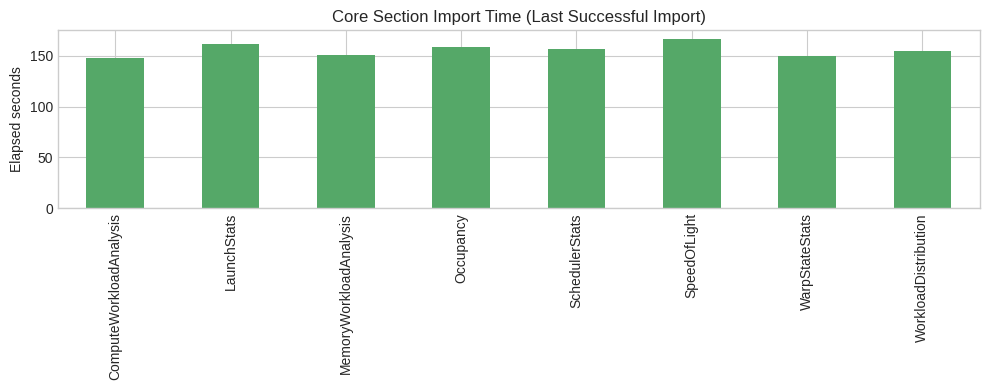

### Import Timing Note
All section sidecars were reused from cache on this run. `attempt_elapsed_sec` shows current-run work, while `import_elapsed_sec` and the chart preserve the last known successful import duration for each section.

### Extraction Warnings
No extraction warnings were recorded for this bundle.

In [19]:
bundle = q("SELECT key, value FROM bundle_metadata ORDER BY key")
bundle_map = dict(zip(bundle["key"], bundle["value"])) if not bundle.empty else {}

session_attempts = q(
    """
    SELECT
        page,
        status,
        timeout_sec,
        ROUND(elapsed_sec, 3) AS attempt_elapsed_sec,
        ROUND(import_elapsed_sec, 3) AS import_elapsed_sec,
        line_count,
        row_count,
        reused_existing
    FROM import_attempts
    ORDER BY page
    """
)
section_attempts = q(
    """
    SELECT
        section_id,
        display_name,
        status,
        timeout_sec,
        ROUND(elapsed_sec, 3) AS attempt_elapsed_sec,
        ROUND(import_elapsed_sec, 3) AS import_elapsed_sec,
        row_count,
        reused_existing
    FROM section_import_attempts
    ORDER BY section_id
    """
)
warnings_df = q("SELECT message FROM extraction_warnings")
launch_scope = q(
    """
    SELECT
        COUNT(DISTINCT launch_id) AS matched_launches,
        MIN(launch_id) AS min_launch_id,
        MAX(launch_id) AS max_launch_id
    FROM section_metric_values
    WHERE launch_id IS NOT NULL
    """
)
sample_scope = q(
    """
    SELECT
        COUNT(*) AS sampled_launches,
        MIN(launch_id) AS sampled_min_launch_id,
        MAX(launch_id) AS sampled_max_launch_id
    FROM sampled_launches
    """
)

matched_launches = int(launch_scope.iloc[0]["matched_launches"] or 0)
sampled_launches = int(sample_scope.iloc[0]["sampled_launches"] or 0)
sample_pct = (100.0 * sampled_launches / matched_launches) if matched_launches else 0.0
completed_sections = int(section_attempts["status"].isin(SUCCESS_STATUSES).sum())
reused_sections = int(section_attempts["reused_existing"].fillna(0).sum())

display_md(
    f"""
    ### Bundle Summary
    - Run ID: `{RUN_ID}`
    - Report path: `{bundle_map.get('rep_path', 'unknown')}`
    - Bundle path: `{ANALYSIS_DIR}`
    - Sections complete: `{completed_sections}/{len(section_attempts)}`
    - Reused completed section sidecars on this run: `{reused_sections}`
    - Matched launches in structured bundle: `{matched_launches}`
    - Sampled launches: `{sampled_launches}` (`{sample_pct:0.2f}%` of matched launches)
    """
)

display_md("### Bundle Metadata")
display(bundle)

display_md("### Section Import Attempts")
display(section_attempts)

display_md("### Session Import Attempts")
display(session_attempts)

if not section_attempts.empty:
    import_time_series = section_attempts["import_elapsed_sec"].where(
        section_attempts["import_elapsed_sec"].notna(),
        section_attempts["attempt_elapsed_sec"],
    )
    if import_time_series.notna().any():
        fig, ax = plt.subplots(figsize=(10, 4))
        import_time_series.index = section_attempts["section_id"]
        import_time_series.plot.bar(ax=ax, color="#55A868")
        ax.set_title("Core Section Import Time (Last Successful Import)")
        ax.set_ylabel("Elapsed seconds")
        ax.set_xlabel("")
        plt.tight_layout()
        plt.show()
    else:
        display_md("""### Core Section Import Time
No successful section import duration has been recorded yet for this bundle.""")

    if section_attempts["reused_existing"].fillna(0).eq(1).all():
        display_md(
            """### Import Timing Note
All section sidecars were reused from cache on this run. `attempt_elapsed_sec` shows current-run work, while `import_elapsed_sec` and the chart preserve the last known successful import duration for each section."""
        )
    elif section_attempts["reused_existing"].fillna(0).any():
        display_md(
            """### Import Timing Note
Some section sidecars were reused from cache on this run. `attempt_elapsed_sec` shows current-run work, while `import_elapsed_sec` preserves the last known successful import duration for reused sections."""
        )

if warnings_df.empty:
    display_md("""### Extraction Warnings
No extraction warnings were recorded for this bundle.""")
else:
    display_md("### Extraction Warnings")
    display(warnings_df)


## Kernel Identity and Match Scope


In [20]:
kernel_df = q(
    """
    SELECT kernel_filter, kernel_name, matched_in_strings, string_occurrences
    FROM kernel_targets
    """
)
identity_df = q(
    """
    SELECT
        process_name,
        device,
        cc,
        COUNT(DISTINCT launch_id) AS launches
    FROM section_metric_values
    WHERE kernel_name IS NOT NULL AND TRIM(kernel_name) != ''
    GROUP BY process_name, device, cc
    ORDER BY launches DESC, process_name
    LIMIT 5
    """
)

kernel_name = kernel_df.iloc[0]["kernel_name"] if not kernel_df.empty else "unknown"
kernel_filter = kernel_df.iloc[0]["kernel_filter"] if not kernel_df.empty else "unknown"
min_launch_id = int(launch_scope.iloc[0]["min_launch_id"]) if matched_launches else 0
max_launch_id = int(launch_scope.iloc[0]["max_launch_id"]) if matched_launches else 0
sampled_min = int(sample_scope.iloc[0]["sampled_min_launch_id"]) if sampled_launches else 0
sampled_max = int(sample_scope.iloc[0]["sampled_max_launch_id"]) if sampled_launches else 0

display_md(
    f"""
    ### Match Scope
    - Target kernel: `{kernel_name}`
    - Recorded kernel filter: `{kernel_filter}`
    - Structured launch coverage: `{matched_launches}` launches spanning IDs `{min_launch_id}` to `{max_launch_id}`
    - Sampled launch coverage: `{sampled_launches}` launches spanning IDs `{sampled_min}` to `{sampled_max}`
    - Sample policy: evenly distributed over observed launch order; the sample is for compact visualization, while run-level averages come from the full structured section imports.
    """
)

display_md("### Kernel Target Table")
display(kernel_df)

display_md("### Process / Device Identity")
display(identity_df)


### Match Scope
- Target kernel: `ampere_sgemm_32x32_sliced1x4_tn`
- Recorded kernel filter: `regex:ampere_sgemm_32x32_sliced1x4_tn`
- Structured launch coverage: `15713` launches spanning IDs `0` to `15712`
- Sampled launch coverage: `250` launches spanning IDs `0` to `15712`
- Sample policy: evenly distributed over observed launch order; the sample is for compact visualization, while run-level averages come from the full structured section imports.

### Kernel Target Table

,kernel_filter,kernel_name,matched_in_strings,string_occurrences
0,regex:ampere_sgemm_32x32_sliced1x4_tn,ampere_sgemm_32x32_sliced1x4_tn,1,47163


### Process / Device Identity

,process_name,device,cc,launches
0,python3.10,0,8.9,15713


## Launch and Occupancy


In [21]:
launch_summary = metric_summaries(["LaunchStats"])
occupancy_summary = metric_summaries(["Occupancy"])

launch_focus = launch_summary[
    launch_summary["metric_name"].isin(
        [
            "# SMs",
            "Block Size",
            "Grid Size",
            "Registers Per Thread",
            "Static Shared Memory Per Block",
            "Driver Shared Memory Per Block",
            "Waves Per SM",
        ]
    )
].reset_index(drop=True)
occupancy_focus = occupancy_summary[
    occupancy_summary["metric_name"].isin(
        [
            "Achieved Occupancy",
            "Theoretical Occupancy",
            "Achieved Active Warps Per SM",
            "Theoretical Active Warps per SM",
        ]
    )
].reset_index(drop=True)
occupancy_limiters = occupancy_summary[
    occupancy_summary["metric_name"].isin(
        [
            "Block Limit Registers",
            "Block Limit Shared Mem",
            "Block Limit Warps",
            "Block Limit SM",
        ]
    )
].reset_index(drop=True)

display_md("### Launch Statistics")
display(launch_focus)

display_md("### Occupancy Summary")
display(occupancy_focus)

display_md("### Occupancy Limiters")
display(occupancy_limiters)

launch_occ_summary = pd.concat([launch_summary, occupancy_summary], ignore_index=True)
display_md(
    f"""
    ### Launch / Occupancy Readout
    - Average `Waves Per SM`: `{num(metric_value(launch_occ_summary, 'LaunchStats', 'Waves Per SM'))}`
    - Achieved occupancy: `{pct(metric_value(launch_occ_summary, 'Occupancy', 'Achieved Occupancy'))}`
    - Theoretical occupancy: `{pct(metric_value(launch_occ_summary, 'Occupancy', 'Theoretical Occupancy'))}`
    - Achieved active warps per SM: `{num(metric_value(launch_occ_summary, 'Occupancy', 'Achieved Active Warps Per SM'))}`
    - Theoretical active warps per SM: `{num(metric_value(launch_occ_summary, 'Occupancy', 'Theoretical Active Warps per SM'))}`
    """
)


### Launch Statistics

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,LaunchStats,# SMs,SM,15713,142.000,142.000,142.000
1,LaunchStats,Block Size,,15713,128.000,128.000,128.000
2,LaunchStats,Driver Shared Memory Per Block,Kbyte/block,15713,1.020,1.020,1.020
3,LaunchStats,Grid Size,,15713,128.000,261.676,352.000
4,LaunchStats,Registers Per Thread,register/thread,15713,86.000,86.000,86.000
5,LaunchStats,Static Shared Memory Per Block,Kbyte/block,15713,32.770,32.770,32.770
6,LaunchStats,Waves Per SM,,15713,0.300,0.614,0.830


### Occupancy Summary

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,Occupancy,Achieved Active Warps Per SM,warp,15713,3.730,7.060,9.760
1,Occupancy,Achieved Occupancy,%,15713,7.780,14.708,20.340
2,Occupancy,Theoretical Active Warps per SM,warp,15713,12.000,12.000,12.000
3,Occupancy,Theoretical Occupancy,%,15713,25.000,25.000,25.000


### Occupancy Limiters

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,Occupancy,Block Limit Registers,block,15713,5.000,5.000,5.000
1,Occupancy,Block Limit SM,block,15713,24.000,24.000,24.000
2,Occupancy,Block Limit Shared Mem,block,15713,3.000,3.000,3.000
3,Occupancy,Block Limit Warps,block,15713,12.000,12.000,12.000


### Launch / Occupancy Readout
- Average `Waves Per SM`: `0.614`
- Achieved occupancy: `14.71%`
- Theoretical occupancy: `25.00%`
- Achieved active warps per SM: `7.060`
- Theoretical active warps per SM: `12.000`

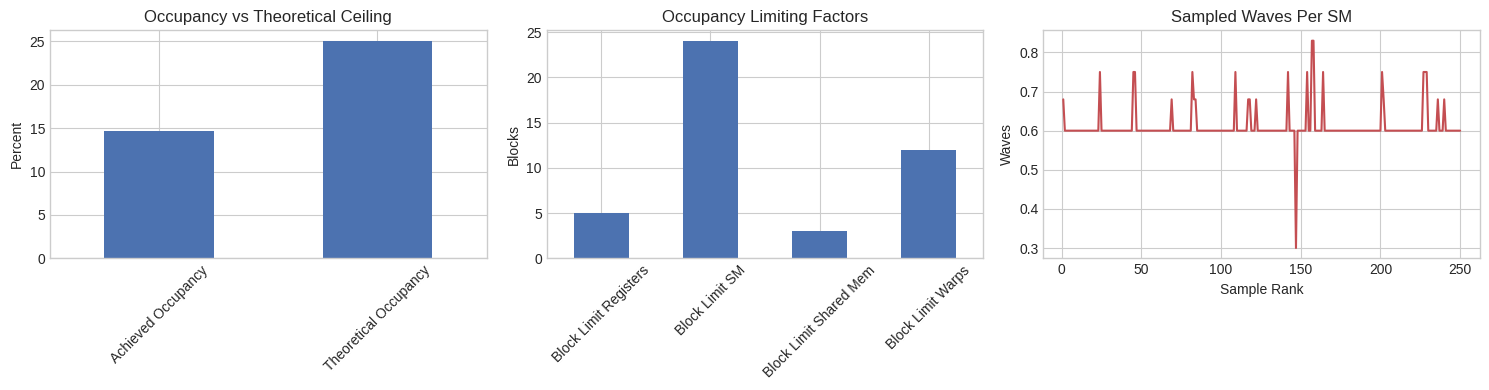

### Sampled Launch / Occupancy Summary

,section_id,metric_name,metric_unit,samples,min_value,median_value,avg_value,max_value
0,LaunchStats,Waves Per SM,,250,0.300,0.600,0.611,0.830
1,Occupancy,Achieved Occupancy,%,250,7.990,14.330,14.632,20.170
2,Occupancy,Theoretical Occupancy,%,250,25.000,25.000,25.000,25.000


In [22]:
occ_pct = pd.Series(
    {
        "Achieved Occupancy": metric_value(occupancy_summary, "Occupancy", "Achieved Occupancy"),
        "Theoretical Occupancy": metric_value(occupancy_summary, "Occupancy", "Theoretical Occupancy"),
    }
)
limiter_series = occupancy_limiters.set_index("metric_name")["avg_value"]

sampled_launch_occ = sampled_metrics(
    [
        ("LaunchStats", "Waves Per SM"),
        ("Occupancy", "Achieved Occupancy"),
        ("Occupancy", "Theoretical Occupancy"),
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_bar(axes[0], occ_pct, "Occupancy vs Theoretical Ceiling", "Percent")
plot_bar(axes[1], limiter_series, "Occupancy Limiting Factors", "Blocks")

sampled_pivot = sampled_launch_occ.pivot_table(
    index="sample_rank",
    columns=["section_id", "metric_name"],
    values="metric_value_num",
    aggfunc="mean",
)
if ("LaunchStats", "Waves Per SM") in sampled_pivot.columns:
    sampled_pivot[("LaunchStats", "Waves Per SM")].plot(ax=axes[2], color="#C44E52")
    axes[2].set_title("Sampled Waves Per SM")
    axes[2].set_ylabel("Waves")
    axes[2].set_xlabel("Sample Rank")
plt.tight_layout()
plt.show()

display_md("### Sampled Launch / Occupancy Summary")
display(sampled_summary(sampled_launch_occ))


## SM / Compute vs Memory


In [23]:
compute_summary = metric_summaries(["ComputeWorkloadAnalysis"])
memory_summary = metric_summaries(["MemoryWorkloadAnalysis"])
sol_summary = metric_summaries(["SpeedOfLight"])

compute_focus = compute_summary[
    compute_summary["metric_name"].isin(
        [
            "SM Busy",
            "Issue Slots Busy",
            "Executed Ipc Active",
            "Executed Ipc Elapsed",
            "Issued Ipc Active",
        ]
    )
].reset_index(drop=True)
memory_focus = memory_summary[
    memory_summary["metric_name"].isin(
        [
            "Memory Throughput",
            "Mem Busy",
            "Mem Pipes Busy",
            "Max Bandwidth",
            "L1/TEX Hit Rate",
            "L2 Hit Rate",
        ]
    )
].reset_index(drop=True)
sol_focus = sol_summary[
    sol_summary["metric_name"].isin(
        [
            "Compute (SM) Throughput",
            "Memory Throughput",
            "DRAM Throughput",
            "L1/TEX Cache Throughput",
            "L2 Cache Throughput",
            "Duration",
        ]
    )
].reset_index(drop=True)

display_md("### Compute Workload Analysis")
display(compute_focus)

display_md("### Memory Workload Analysis")
display(memory_focus)

display_md("### GPU Speed Of Light Throughput")
display(sol_focus)


### Compute Workload Analysis

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,ComputeWorkloadAnalysis,Executed Ipc Active,inst/cycle,15713,0.680,1.170,1.830
1,ComputeWorkloadAnalysis,Executed Ipc Elapsed,inst/cycle,15713,0.480,0.912,1.540
2,ComputeWorkloadAnalysis,Issue Slots Busy,%,15713,17.100,29.520,45.900
3,ComputeWorkloadAnalysis,Issued Ipc Active,inst/cycle,15713,0.680,1.181,1.840
4,ComputeWorkloadAnalysis,SM Busy,%,15713,17.100,29.520,45.900


### Memory Workload Analysis

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,MemoryWorkloadAnalysis,L1/TEX Hit Rate,%,15713,0.000,7.221,41.810
1,MemoryWorkloadAnalysis,L2 Hit Rate,%,15713,48.940,84.467,96.320
2,MemoryWorkloadAnalysis,Max Bandwidth,%,15713,15.810,28.089,48.420
3,MemoryWorkloadAnalysis,Mem Busy,%,15713,17.200,32.876,56.610
4,MemoryWorkloadAnalysis,Mem Pipes Busy,%,15713,14.820,28.086,48.420
5,MemoryWorkloadAnalysis,Memory Throughput,Gbyte/s,15713,13.220,101.480,145.630


### GPU Speed Of Light Throughput

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,SpeedOfLight,Compute (SM) Throughput,%,15713,14.820,28.086,48.420
1,SpeedOfLight,DRAM Throughput,%,15713,1.550,11.822,17.010
2,SpeedOfLight,Duration,us,15713,8.190,14.086,39.940
3,SpeedOfLight,L1/TEX Cache Throughput,%,15713,24.100,42.184,67.310
4,SpeedOfLight,L2 Cache Throughput,%,15713,3.350,13.651,28.840
5,SpeedOfLight,Memory Throughput,%,15713,17.200,32.876,56.610


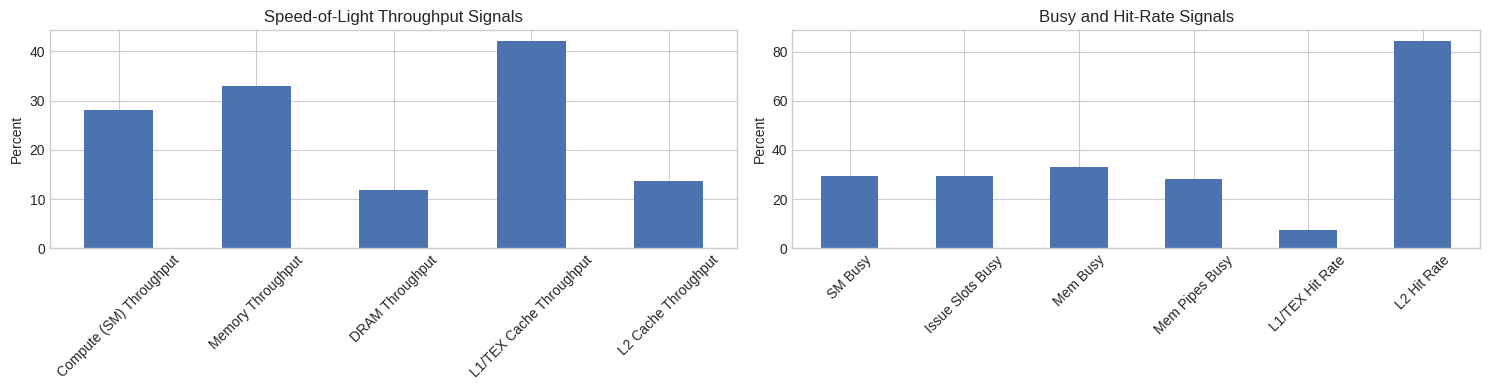

In [24]:
throughput_pct = pd.Series(
    {
        "Compute (SM) Throughput": metric_value(sol_summary, "SpeedOfLight", "Compute (SM) Throughput"),
        "Memory Throughput": metric_value(sol_summary, "SpeedOfLight", "Memory Throughput"),
        "DRAM Throughput": metric_value(sol_summary, "SpeedOfLight", "DRAM Throughput"),
        "L1/TEX Cache Throughput": metric_value(sol_summary, "SpeedOfLight", "L1/TEX Cache Throughput"),
        "L2 Cache Throughput": metric_value(sol_summary, "SpeedOfLight", "L2 Cache Throughput"),
    }
)
busy_and_hit_rates = pd.Series(
    {
        "SM Busy": metric_value(compute_summary, "ComputeWorkloadAnalysis", "SM Busy"),
        "Issue Slots Busy": metric_value(compute_summary, "ComputeWorkloadAnalysis", "Issue Slots Busy"),
        "Mem Busy": metric_value(memory_summary, "MemoryWorkloadAnalysis", "Mem Busy"),
        "Mem Pipes Busy": metric_value(memory_summary, "MemoryWorkloadAnalysis", "Mem Pipes Busy"),
        "L1/TEX Hit Rate": metric_value(memory_summary, "MemoryWorkloadAnalysis", "L1/TEX Hit Rate"),
        "L2 Hit Rate": metric_value(memory_summary, "MemoryWorkloadAnalysis", "L2 Hit Rate"),
    }
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_bar(axes[0], throughput_pct, "Speed-of-Light Throughput Signals", "Percent")
plot_bar(axes[1], busy_and_hit_rates, "Busy and Hit-Rate Signals", "Percent")
plt.tight_layout()
plt.show()


## GPU and Memory Workload Distribution


In [25]:
workload_summary = metric_summaries(["WorkloadDistribution"])
workload_focus = summary_rows(workload_summary, ["Active Cycles", "Elapsed Cycles"])

display_md("### WorkloadDistribution Summary")
display(workload_focus)

workload_resources = ["SM", "SMSP", "L1", "L2", "DRAM"]
workload_rows = []
workload_pairs = []

for resource in workload_resources:
    active_name = f"Average {resource} Active Cycles"
    elapsed_name = f"Total {resource} Elapsed Cycles"
    active_value = metric_value(workload_summary, "WorkloadDistribution", active_name)
    elapsed_value = metric_value(workload_summary, "WorkloadDistribution", elapsed_name)
    if pd.isna(active_value) and pd.isna(elapsed_value):
        continue
    workload_rows.append(
        {
            "resource": resource,
            "active_metric": active_name,
            "avg_active_cycles": active_value,
            "elapsed_metric": elapsed_name,
            "avg_elapsed_cycles": elapsed_value,
            "active_over_elapsed_pct": ratio_pct(active_value, elapsed_value),
        }
    )
    if not pd.isna(active_value):
        workload_pairs.append(("WorkloadDistribution", active_name))
    if not pd.isna(elapsed_value):
        workload_pairs.append(("WorkloadDistribution", elapsed_name))

workload_resource_df = pd.DataFrame(workload_rows)

display_md("### Resource-Level Readout")
display(workload_resource_df)


### WorkloadDistribution Summary

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,WorkloadDistribution,Average DRAM Active Cycles,cycle,15713,1198.670,14306.763,32745.330
1,WorkloadDistribution,Average L1 Active Cycles,cycle,15713,6406.440,11729.252,34626.390
2,WorkloadDistribution,Average L2 Active Cycles,cycle,15713,2353.210,9160.114,41433.500
3,WorkloadDistribution,Average SM Active Cycles,cycle,15713,6406.440,11729.252,34626.390
4,WorkloadDistribution,Average SMSP Active Cycles,cycle,15713,6264.440,11336.620,34216.960
5,WorkloadDistribution,Total DRAM Elapsed Cycles,cycle,15713,879616.000,1513046.577,4302848.000
6,WorkloadDistribution,Total L1 Elapsed Cycles,cycle,15713,1231368.000,2120010.925,5891770.000
7,WorkloadDistribution,Total L2 Elapsed Cycles,cycle,15713,537168.000,913205.392,2578368.000
8,WorkloadDistribution,Total SM Elapsed Cycles,cycle,15713,1231368.000,2120010.925,5891770.000
9,WorkloadDistribution,Total SMSP Elapsed Cycles,cycle,15713,4925472.000,8480043.699,23567080.000


### Resource-Level Readout

,resource,active_metric,avg_active_cycles,elapsed_metric,avg_elapsed_cycles,active_over_elapsed_pct
0,SM,Average SM Active Cycles,11729.252,Total SM Elapsed Cycles,2120010.925,0.553
1,SMSP,Average SMSP Active Cycles,11336.620,Total SMSP Elapsed Cycles,8480043.699,0.134
2,L1,Average L1 Active Cycles,11729.252,Total L1 Elapsed Cycles,2120010.925,0.553
3,L2,Average L2 Active Cycles,9160.114,Total L2 Elapsed Cycles,913205.392,1.003
4,DRAM,Average DRAM Active Cycles,14306.763,Total DRAM Elapsed Cycles,1513046.577,0.946


### Sampled WorkloadDistribution Summary

,section_id,metric_name,metric_unit,samples,min_value,median_value,avg_value,max_value
0,WorkloadDistribution,Average DRAM Active Cycles,cycle,250,1574.670,14932.665,14178.747,32621.330
1,WorkloadDistribution,Average L1 Active Cycles,cycle,250,6654.670,8914.055,11710.943,34531.270
2,WorkloadDistribution,Average L2 Active Cycles,cycle,250,2844.520,5801.645,9187.235,41251.560
3,WorkloadDistribution,Average SM Active Cycles,cycle,250,6654.670,8914.055,11710.943,34531.270
4,WorkloadDistribution,Average SMSP Active Cycles,cycle,250,6349.500,8521.365,11314.820,34029.000
5,WorkloadDistribution,Total DRAM Elapsed Cycles,cycle,250,909312.000,1159680.000,1499969.536,4171776.000
6,WorkloadDistribution,Total L1 Elapsed Cycles,cycle,250,1275392.000,1622168.000,2101674.848,5847440.000
7,WorkloadDistribution,Total L2 Elapsed Cycles,cycle,250,550944.000,697128.000,905004.288,2531376.000
8,WorkloadDistribution,Total SM Elapsed Cycles,cycle,250,1275392.000,1622168.000,2101674.848,5847440.000
9,WorkloadDistribution,Total SMSP Elapsed Cycles,cycle,250,5101568.000,6488672.000,8406699.392,23389760.000


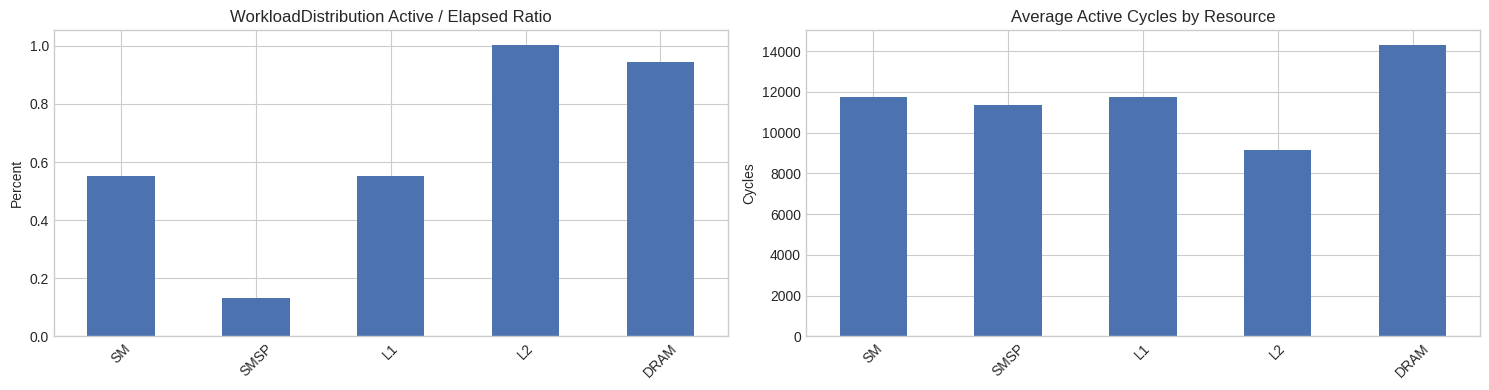

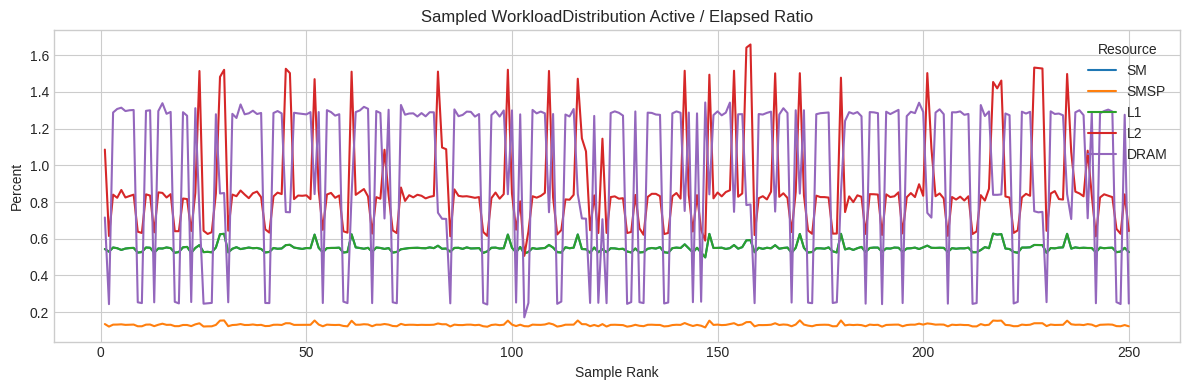

In [26]:
workload_util_series = (
    workload_resource_df.set_index("resource")["active_over_elapsed_pct"].dropna()
    if not workload_resource_df.empty
    else pd.Series(dtype=float)
)
workload_active_series = (
    workload_resource_df.set_index("resource")["avg_active_cycles"].dropna()
    if not workload_resource_df.empty
    else pd.Series(dtype=float)
)

sampled_workload = sampled_metrics(workload_pairs)
display_md("### Sampled WorkloadDistribution Summary")
display(sampled_summary(sampled_workload))

sampled_workload_pivot = sampled_workload.pivot_table(
    index="sample_rank",
    columns="metric_name",
    values="metric_value_num",
    aggfunc="mean",
)
sampled_workload_ratio_df = pd.DataFrame(index=sampled_workload_pivot.index)

for resource in workload_resources:
    active_name = f"Average {resource} Active Cycles"
    elapsed_name = f"Total {resource} Elapsed Cycles"
    if active_name in sampled_workload_pivot.columns and elapsed_name in sampled_workload_pivot.columns:
        sampled_workload_ratio_df[resource] = 100.0 * sampled_workload_pivot[active_name] / sampled_workload_pivot[elapsed_name].replace(0, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
if not workload_util_series.empty:
    plot_bar(axes[0], workload_util_series, "WorkloadDistribution Active / Elapsed Ratio", "Percent")
else:
    axes[0].set_visible(False)

if not workload_active_series.empty:
    plot_bar(axes[1], workload_active_series, "Average Active Cycles by Resource", "Cycles")
else:
    axes[1].set_visible(False)

plt.tight_layout()
plt.show()

if sampled_workload_ratio_df.empty:
    display_md("""### Sampled WorkloadDistribution Chart
No sampled active/elapsed pairs were available for this bundle.""")
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    for resource in sampled_workload_ratio_df.columns:
        sampled_workload_ratio_df[resource].plot(ax=ax, label=resource)
    ax.set_title("Sampled WorkloadDistribution Active / Elapsed Ratio")
    ax.set_xlabel("Sample Rank")
    ax.set_ylabel("Percent")
    ax.legend(title="Resource")
    plt.tight_layout()
    plt.show()


## Scheduler and Warp Behavior


In [27]:
scheduler_summary = metric_summaries(["SchedulerStats"])
warp_summary = metric_summaries(["WarpStateStats"])

scheduler_focus = scheduler_summary[
    scheduler_summary["metric_name"].isin(
        [
            "Active Warps Per Scheduler",
            "Eligible Warps Per Scheduler",
            "Issued Warp Per Scheduler",
            "No Eligible",
            "One or More Eligible",
        ]
    )
].reset_index(drop=True)
warp_focus = warp_summary[
    warp_summary["metric_name"].isin(
        [
            "Avg. Active Threads Per Warp",
            "Avg. Not Predicated Off Threads Per Warp",
            "Warp Cycles Per Executed Instruction",
            "Warp Cycles Per Issued Instruction",
        ]
    )
].reset_index(drop=True)

display_md("### Scheduler Statistics")
display(scheduler_focus)

display_md("### Warp State Statistics")
display(warp_focus)


### Scheduler Statistics

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,SchedulerStats,Active Warps Per Scheduler,warp,15713,0.990,1.838,2.460
1,SchedulerStats,Eligible Warps Per Scheduler,warp,15713,0.180,0.387,0.690
2,SchedulerStats,Issued Warp Per Scheduler,,15713,0.180,0.308,0.460
3,SchedulerStats,No Eligible,%,15713,53.700,69.239,81.500
4,SchedulerStats,One or More Eligible,%,15713,18.500,30.761,46.300


### Warp State Statistics

,section_id,metric_name,metric_unit,value_count,min_value,avg_value,max_value
0,WarpStateStats,Avg. Active Threads Per Warp,,15713,32.000,32.000,32.000
1,WarpStateStats,Avg. Not Predicated Off Threads Per Warp,,15713,30.930,31.351,31.750
2,WarpStateStats,Warp Cycles Per Executed Instruction,cycle,15713,4.460,6.102,6.610
3,WarpStateStats,Warp Cycles Per Issued Instruction,cycle,15713,4.450,6.043,6.520


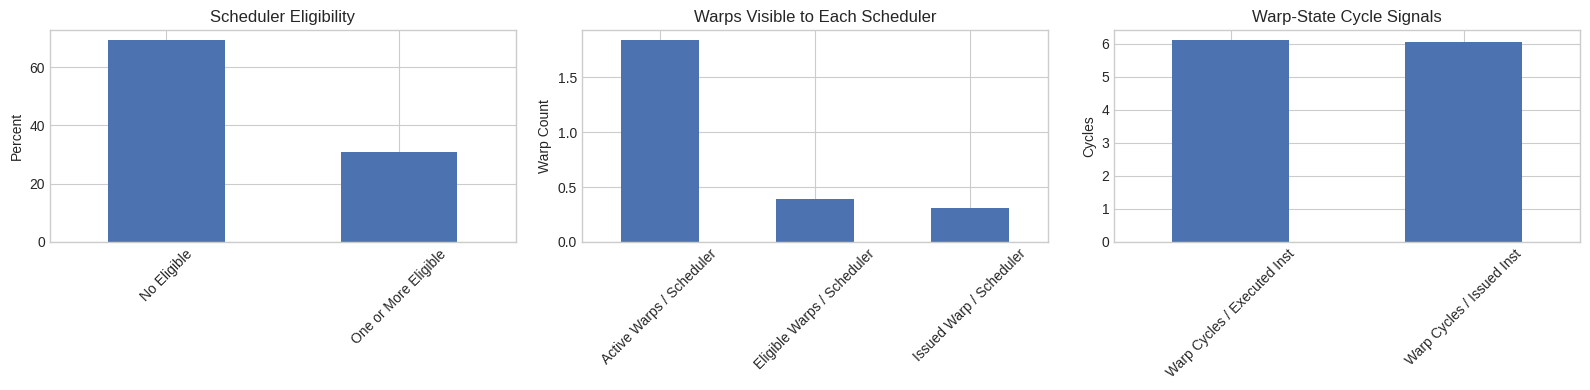

In [28]:
scheduler_pct = pd.Series(
    {
        "No Eligible": metric_value(scheduler_summary, "SchedulerStats", "No Eligible"),
        "One or More Eligible": metric_value(scheduler_summary, "SchedulerStats", "One or More Eligible"),
    }
)
scheduler_warps = pd.Series(
    {
        "Active Warps / Scheduler": metric_value(scheduler_summary, "SchedulerStats", "Active Warps Per Scheduler"),
        "Eligible Warps / Scheduler": metric_value(scheduler_summary, "SchedulerStats", "Eligible Warps Per Scheduler"),
        "Issued Warp / Scheduler": metric_value(scheduler_summary, "SchedulerStats", "Issued Warp Per Scheduler"),
    }
)
warp_cycles = pd.Series(
    {
        "Warp Cycles / Executed Inst": metric_value(warp_summary, "WarpStateStats", "Warp Cycles Per Executed Instruction"),
        "Warp Cycles / Issued Inst": metric_value(warp_summary, "WarpStateStats", "Warp Cycles Per Issued Instruction"),
    }
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_bar(axes[0], scheduler_pct, "Scheduler Eligibility", "Percent")
plot_bar(axes[1], scheduler_warps, "Warps Visible to Each Scheduler", "Warp Count")
plot_bar(axes[2], warp_cycles, "Warp-State Cycle Signals", "Cycles")
plt.tight_layout()
plt.show()


## Nsight Guidance Cards


In [29]:
rules_df = q(
    """
    SELECT
        section_id,
        rule_name,
        rule_type,
        MAX(rule_description) AS rule_description,
        MAX(estimated_speedup_type) AS estimated_speedup_type,
        ROUND(MAX(estimated_speedup), 2) AS max_estimated_speedup,
        COUNT(DISTINCT launch_id) AS launches_covered
    FROM section_metric_values
    WHERE rule_name IS NOT NULL AND TRIM(rule_name) != ''
    GROUP BY section_id, rule_name, rule_type
    ORDER BY launches_covered DESC, section_id, rule_name
    """
)
if matched_launches:
    rules_df["launch_coverage_pct"] = (100.0 * rules_df["launches_covered"] / matched_launches).round(2)

display(rules_df)

cards = []
for row in rules_df.head(8).itertuples(index=False):
    speedup = "not quantified"
    if not pd.isna(row.max_estimated_speedup):
        speedup_type = row.estimated_speedup_type or "estimated"
        speedup = f"{row.max_estimated_speedup:0.2f} ({speedup_type})"
    description = row.rule_description if row.rule_description else "No structured rule description was stored for this row."
    coverage = f"{row.launches_covered} launches"
    if "launch_coverage_pct" in rules_df.columns:
        coverage += f" ({getattr(row, 'launch_coverage_pct', np.nan):0.2f}% of matched launches)"
    cards.append(
        dedent(
            f"""
            ### {row.rule_name} [{row.section_id}]
            - Rule type: `{row.rule_type or 'n/a'}`
            - Launch coverage: `{coverage}`
            - Max estimated speedup: `{speedup}`
            - Description: {description}
            """
        ).strip()
    )

display_md("\n\n".join(cards) if cards else "No structured rules were captured in the section rows.")


,section_id,rule_name,rule_type,rule_description,estimated_speedup_type,max_estimated_speedup,launches_covered,launch_coverage_pct
0,Occupancy,TheoreticalOccupancy,OPT,The 3.00 theoretical warps per scheduler this kernel can issue according to its occupancy are below the hardware maximum of 12. This kernel's theoretical oc...,global,75.000,15713,100.000
1,SchedulerStats,IssueSlotUtilization,OPT,"Every scheduler is capable of issuing one instruction per cycle, but for this kernel each scheduler only issues an instruction every 5.4 cycles. This might ...",local,81.500,15713,100.000
2,SpeedOfLight,SOLBottleneck,OPT,"This kernel grid is too small to fill the available resources on this device, resulting in only 0.8 full waves across all SMs. Look at Launch Statistics for...",,NaN,15713,100.000
3,LaunchStats,LaunchConfiguration,OPT,"The grid for this launch is configured to execute only 128 blocks, which is less than the GPU's 142 multiprocessors. This can underutilize some multiprocess...",global,9.860,13845,88.110
4,Occupancy,AchievedOccupancy,OPT,The difference between calculated theoretical (25.0%) and measured achieved occupancy (8.5%) can be the result of warp scheduling overheads or workload imba...,global,68.880,13304,84.670
5,ComputeWorkloadAnalysis,HighPipeUtilization,OPT,All compute pipelines are under-utilized. Either this workload is very small or it doesn't issue enough warps per scheduler. Check the Launch Statistics and...,local,88.390,10015,63.740
6,ComputeWorkloadAnalysis,HighPipeUtilization,INF,"FMA is the highest-utilized pipeline (30.2%) based on active cycles, taking into account the rates of its different instructions. It executes 32-bit floatin...",,NaN,5698,36.260
7,WarpStateStats,CPIStall,INF,Check the Warp Stall Sampling (All Samples) table for the top stall locations in your source based on sampling data. The Kernel Profiling Guide (https://doc...,,NaN,3409,21.700
8,WarpStateStats,CPIStall,OPT,"On average, each warp of this kernel spends 1.9 cycles being stalled waiting on a fixed latency execution dependency. Typically, this stall reason should be...",global,31.700,3409,21.700
9,WorkloadDistribution,WorkloadImbalance,OPT,"One or more SMs have a much lower number of active cycles than the average number of active cycles. Maximum instance value is 7.86% above the average, while...",global,16.330,3217,20.470


### TheoreticalOccupancy [Occupancy]
- Rule type: `OPT`
- Launch coverage: `15713 launches (100.00% of matched launches)`
- Max estimated speedup: `75.00 (global)`
- Description: The 3.00 theoretical warps per scheduler this kernel can issue according to its occupancy are below the hardware maximum of 12. This kernel's theoretical occupancy (25.0%) is limited by the required amount of shared memory.

### IssueSlotUtilization [SchedulerStats]
- Rule type: `OPT`
- Launch coverage: `15713 launches (100.00% of matched launches)`
- Max estimated speedup: `81.50 (local)`
- Description: Every scheduler is capable of issuing one instruction per cycle, but for this kernel each scheduler only issues an instruction every 5.4 cycles. This might leave hardware resources underutilized and may lead to less optimal performance. Out of the maximum of 12 warps per scheduler, this kernel allocates an average of 1.03 active warps per scheduler, but only an average of 0.19 warps were eligible per cycle. Eligible warps are the subset of active warps that are ready to issue their next instruction. Every cycle with no eligible warp results in no instruction being issued and the issue slot remains unused. To increase the number of eligible warps, reduce the time the active warps are stalled by inspecting the top stall reasons on the Warp State Statistics and Source Counters sections.

### SOLBottleneck [SpeedOfLight]
- Rule type: `OPT`
- Launch coverage: `15713 launches (100.00% of matched launches)`
- Max estimated speedup: `not quantified`
- Description: This kernel grid is too small to fill the available resources on this device, resulting in only 0.8 full waves across all SMs. Look at Launch Statistics for more details.

### LaunchConfiguration [LaunchStats]
- Rule type: `OPT`
- Launch coverage: `13845 launches (88.11% of matched launches)`
- Max estimated speedup: `9.86 (global)`
- Description: The grid for this launch is configured to execute only 128 blocks, which is less than the GPU's 142 multiprocessors. This can underutilize some multiprocessors. If you do not intend to execute this kernel concurrently with other workloads, consider reducing the block size to have at least one block per multiprocessor or increase the size of the grid to fully utilize the available hardware resources. See the Hardware Model (https://docs.nvidia.com/nsight-compute/ProfilingGuide/index.html#metrics-hw-model) description for more details on launch configurations.

### AchievedOccupancy [Occupancy]
- Rule type: `OPT`
- Launch coverage: `13304 launches (84.67% of matched launches)`
- Max estimated speedup: `68.88 (global)`
- Description: The difference between calculated theoretical (25.0%) and measured achieved occupancy (8.5%) can be the result of warp scheduling overheads or workload imbalances during the kernel execution. Load imbalances can occur between warps within a block as well as across blocks of the same kernel. See the CUDA Best Practices Guide (https://docs.nvidia.com/cuda/cuda-c-best-practices-guide/index.html#occupancy) for more details on optimizing occupancy.

### HighPipeUtilization [ComputeWorkloadAnalysis]
- Rule type: `OPT`
- Launch coverage: `10015 launches (63.74% of matched launches)`
- Max estimated speedup: `88.39 (local)`
- Description: All compute pipelines are under-utilized. Either this workload is very small or it doesn't issue enough warps per scheduler. Check the Launch Statistics and Scheduler Statistics sections for further details.

### HighPipeUtilization [ComputeWorkloadAnalysis]
- Rule type: `INF`
- Launch coverage: `5698 launches (36.26% of matched launches)`
- Max estimated speedup: `not quantified`
- Description: FMA is the highest-utilized pipeline (30.2%) based on active cycles, taking into account the rates of its different instructions. It executes 32-bit floating point (FADD, FMUL, FMAD, ...) and integer (IMUL, IMAD) operations. It is well-utilized, but should not be a bottleneck.

### CPIStall [WarpStateStats]
- Rule type: `INF`
- Launch coverage: `3409 launches (21.70% of matched launches)`
- Max estimated speedup: `not quantified`
- Description: Check the Warp Stall Sampling (All Samples) table for the top stall locations in your source based on sampling data. The Kernel Profiling Guide (https://docs.nvidia.com/nsight-compute/ProfilingGuide/index.html#metrics-reference) provides more details on each stall reason.

## Per-launch Distributions


### Sampled Distribution Summary

,section_id,metric_name,metric_unit,samples,min_value,median_value,avg_value,max_value
0,ComputeWorkloadAnalysis,SM Busy,%,250,17.590,27.580,29.491,45.540
1,LaunchStats,Waves Per SM,,250,0.300,0.600,0.611,0.830
2,MemoryWorkloadAnalysis,Memory Throughput,Gbyte/s,250,17.690,131.485,100.456,138.500
3,Occupancy,Achieved Occupancy,%,250,7.990,14.330,14.632,20.170
4,SchedulerStats,Eligible Warps Per Scheduler,warp,250,0.190,0.360,0.387,0.690
5,SpeedOfLight,Duration,us,250,8.480,10.780,13.964,38.720
6,WorkloadDistribution,Average DRAM Active Cycles,cycle,250,1574.670,14932.665,14178.747,32621.330


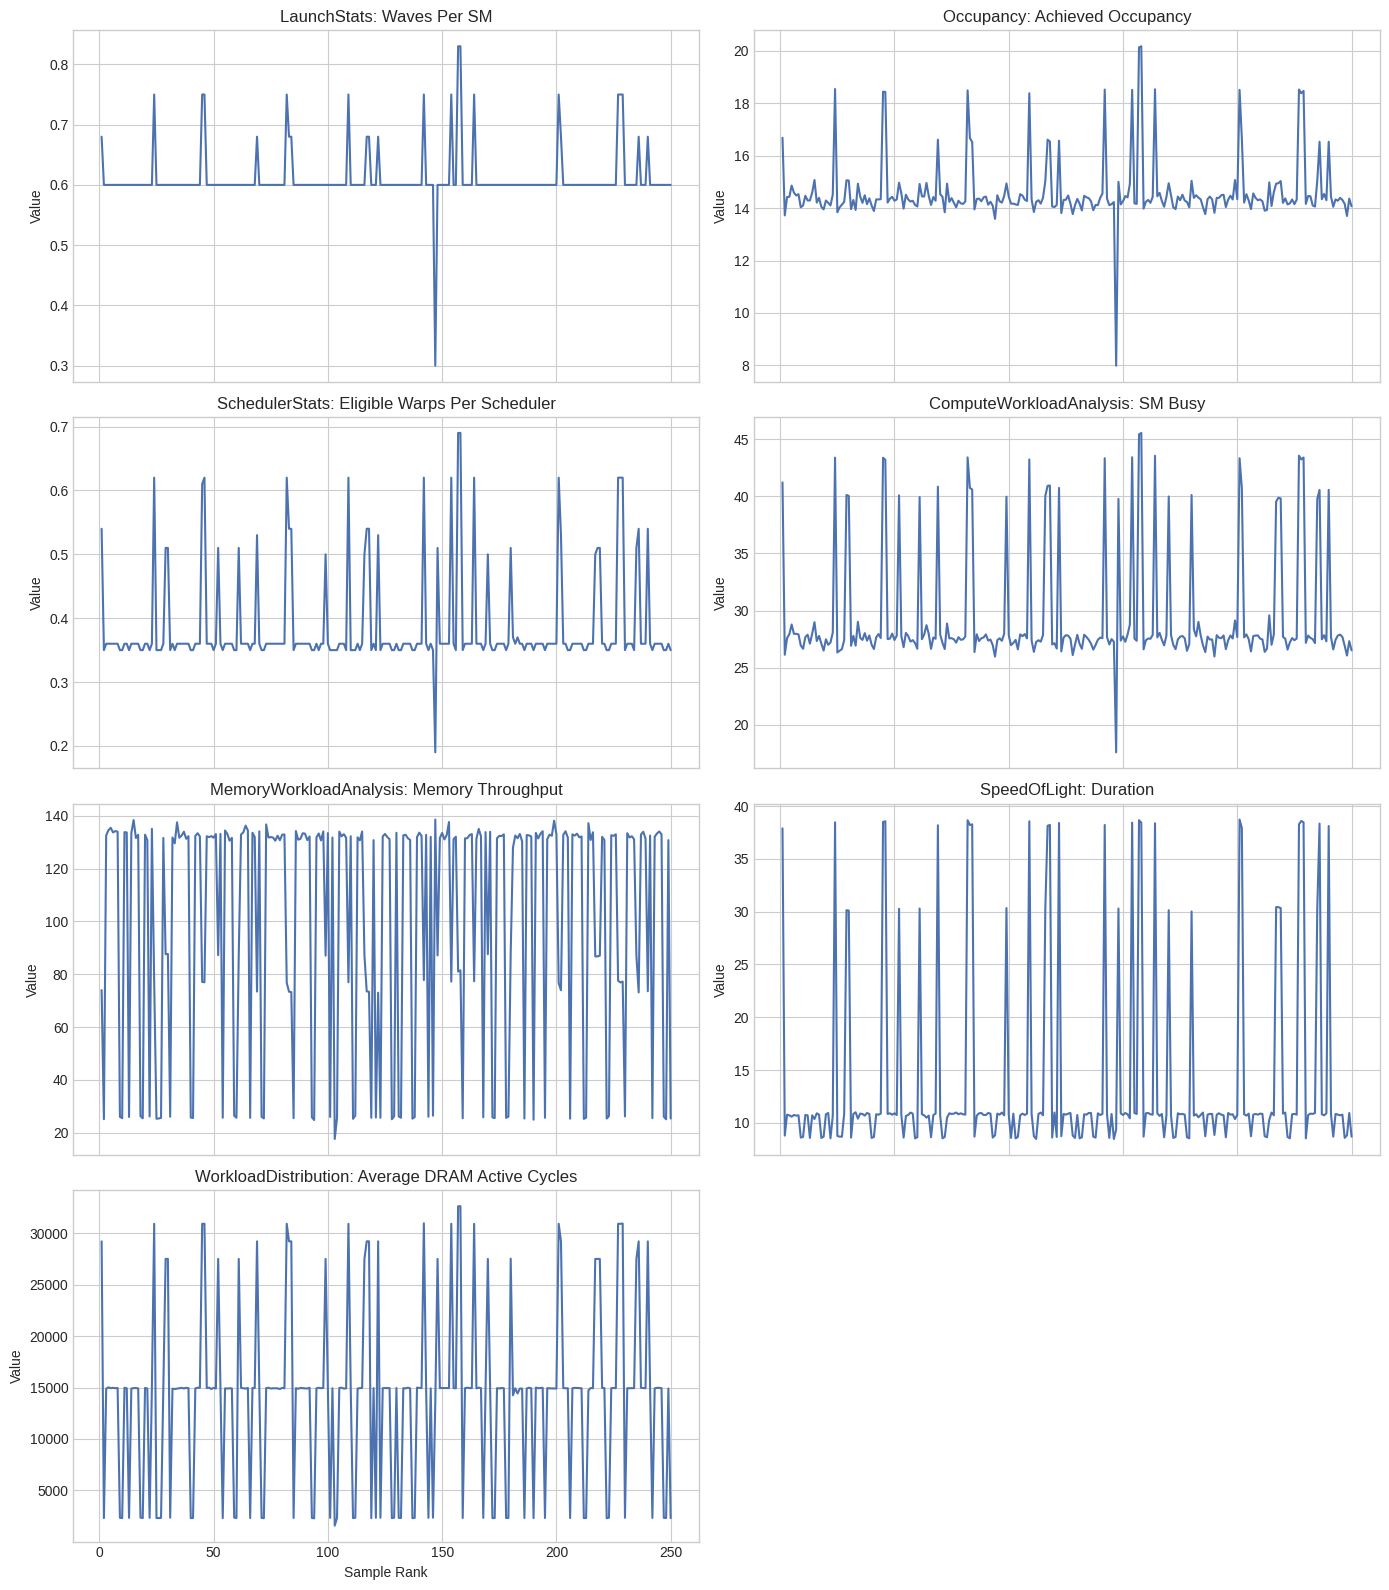

In [30]:
distribution_pairs = [
    ("LaunchStats", "Waves Per SM"),
    ("Occupancy", "Achieved Occupancy"),
    ("SchedulerStats", "Eligible Warps Per Scheduler"),
    ("ComputeWorkloadAnalysis", "SM Busy"),
    ("MemoryWorkloadAnalysis", "Memory Throughput"),
    ("SpeedOfLight", "Duration"),
    ("WorkloadDistribution", "Average DRAM Active Cycles"),
]
sampled_distribution_df = sampled_metrics(distribution_pairs)

display_md("### Sampled Distribution Summary")
display(sampled_summary(sampled_distribution_df))

pivot = sampled_distribution_df.pivot_table(
    index="sample_rank",
    columns=["section_id", "metric_name"],
    values="metric_value_num",
    aggfunc="mean",
)

ncols = 2
nrows = int(np.ceil(len(distribution_pairs) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True)
axes = np.atleast_1d(axes).reshape(nrows, ncols)
for ax, pair in zip(axes.flat, distribution_pairs):
    if pair in pivot.columns:
        pivot[pair].plot(ax=ax, color="#4C72B0")
        ax.set_title(f"{pair[0]}: {pair[1]}")
        ax.set_xlabel("Sample Rank")
        ax.set_ylabel("Value")
    else:
        ax.set_visible(False)
for ax in axes.flat[len(distribution_pairs):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


## Guided Interpretation


In [31]:
all_summary = metric_summaries(
    [
        "LaunchStats",
        "Occupancy",
        "SchedulerStats",
        "WarpStateStats",
        "ComputeWorkloadAnalysis",
        "MemoryWorkloadAnalysis",
        "SpeedOfLight",
        "WorkloadDistribution",
    ]
)

waves = metric_value(all_summary, "LaunchStats", "Waves Per SM")
achieved_occ = metric_value(all_summary, "Occupancy", "Achieved Occupancy")
theoretical_occ = metric_value(all_summary, "Occupancy", "Theoretical Occupancy")
eligible_warps = metric_value(all_summary, "SchedulerStats", "Eligible Warps Per Scheduler")
no_eligible = metric_value(all_summary, "SchedulerStats", "No Eligible")
sm_busy = metric_value(all_summary, "ComputeWorkloadAnalysis", "SM Busy")
mem_busy = metric_value(all_summary, "MemoryWorkloadAnalysis", "Mem Busy")
compute_throughput = metric_value(all_summary, "SpeedOfLight", "Compute (SM) Throughput")
memory_throughput = metric_value(all_summary, "SpeedOfLight", "Memory Throughput")
l2_hit = metric_value(all_summary, "MemoryWorkloadAnalysis", "L2 Hit Rate")
duration_us = metric_value(all_summary, "SpeedOfLight", "Duration")

workload_ratio_series = (
    workload_resource_df.set_index("resource")["active_over_elapsed_pct"].dropna()
    if "workload_resource_df" in globals() and not workload_resource_df.empty
    else pd.Series(dtype=float)
)
if workload_ratio_series.empty:
    workload_text = "WorkloadDistribution metrics were not available for this bundle."
else:
    workload_top_resource = workload_ratio_series.sort_values(ascending=False).index[0]
    workload_top_ratio = workload_ratio_series.max()
    workload_pairs_text = ", ".join(
        f"{resource} {value:0.2f}%" for resource, value in workload_ratio_series.items()
    )
    workload_text = (
        f"WorkloadDistribution active/elapsed ratios remain low across the hierarchy ({workload_pairs_text}); "
        f"the highest observed ratio is `{workload_top_resource}` at `{pct(workload_top_ratio)}`."
    )

top_rule = rules_df.iloc[0] if not rules_df.empty else None
top_rule_text = "No structured rule/advice rows were captured."
if top_rule is not None:
    speedup_text = "not quantified"
    if not pd.isna(top_rule.max_estimated_speedup):
        speedup_text = f"{top_rule.max_estimated_speedup:0.2f} ({top_rule.estimated_speedup_type or 'estimated'})"
    top_rule_text = (
        f"Top repeated guidance card: `{top_rule.rule_name}` in `{top_rule.section_id}` covering "
        f"{int(top_rule.launches_covered)} launches with max estimated speedup `{speedup_text}`."
    )

display_md(
    f"""
    ### Structured Narrative
    - Launch scale is modest for the device: average `Waves Per SM` is `{num(waves)}`, so this kernel does not keep many full waves resident at once.
    - Occupancy stays low relative to its own ceiling: achieved occupancy is `{pct(achieved_occ)}` versus theoretical occupancy `{pct(theoretical_occ)}`.
    - Scheduler pressure remains weak: eligible warps per scheduler average `{num(eligible_warps)}` and schedulers report `No Eligible` `{pct(no_eligible)}` of the time.
    - Compute and memory pipelines both look active but not saturated: `SM Busy` is `{pct(sm_busy)}`, `Mem Busy` is `{pct(mem_busy)}`, `Compute (SM) Throughput` is `{pct(compute_throughput)}`, and `Memory Throughput` is `{pct(memory_throughput)}`.
    - WorkloadDistribution adds hierarchy context rather than overturning the main story: {workload_text}
    - Memory locality is mixed rather than catastrophic: `L2 Hit Rate` averages `{pct(l2_hit)}` while the average sampled kernel duration is `{num(duration_us)}` microseconds.
    - {top_rule_text}

    This combination still reads more like an underfilled / low-eligibility kernel than a kernel that is simply pinned against a single throughput ceiling. The added workload-distribution section suggests activity is spread across the hierarchy, but it does not reveal a single saturated tier that would displace the launch, occupancy, scheduler, and speed-of-light evidence.
    """
)


### Structured Narrative
- Launch scale is modest for the device: average `Waves Per SM` is `0.614`, so this kernel does not keep many full waves resident at once.
- Occupancy stays low relative to its own ceiling: achieved occupancy is `14.71%` versus theoretical occupancy `25.00%`.
- Scheduler pressure remains weak: eligible warps per scheduler average `0.387` and schedulers report `No Eligible` `69.24%` of the time.
- Compute and memory pipelines both look active but not saturated: `SM Busy` is `29.52%`, `Mem Busy` is `32.88%`, `Compute (SM) Throughput` is `28.09%`, and `Memory Throughput` is `32.88%`.
- WorkloadDistribution adds hierarchy context rather than overturning the main story: WorkloadDistribution active/elapsed ratios remain low across the hierarchy (SM 0.55%, SMSP 0.13%, L1 0.55%, L2 1.00%, DRAM 0.95%); the highest observed ratio is `L2` at `1.00%`.
- Memory locality is mixed rather than catastrophic: `L2 Hit Rate` averages `84.47%` while the average sampled kernel duration is `14.086` microseconds.
- Top repeated guidance card: `TheoreticalOccupancy` in `Occupancy` covering 15713 launches with max estimated speedup `75.00 (global)`.

This combination still reads more like an underfilled / low-eligibility kernel than a kernel that is simply pinned against a single throughput ceiling. The added workload-distribution section suggests activity is spread across the hierarchy, but it does not reveal a single saturated tier that would displace the launch, occupancy, scheduler, and speed-of-light evidence.

## Coverage Gaps


In [32]:
coverage_gaps = pd.DataFrame(
    [
        {
            "area": "Core structured views",
            "status": "covered",
            "details": "Launch, Occupancy, Scheduler, Warp State, Compute Workload, Memory Workload, Speed of Light, and WorkloadDistribution are all imported and surfaced in this notebook.",
        },
        {
            "area": "Nsight guidance cards",
            "status": "covered",
            "details": "Structured rule rows are shown directly from section imports rather than only from embedded report strings.",
        },
        {
            "area": "GPU and Memory Workload Distribution",
            "status": "covered",
            "details": "The default core profile now imports WorkloadDistribution, and the notebook surfaces raw cycle metrics, derived active/elapsed ratios, and sampled-launch charts.",
        },
        {
            "area": "Source / instruction views",
            "status": "deferred",
            "details": "Not part of the default capture profile and still outside the current notebook scope.",
        },
        {
            "area": "Full Nsight Compute UI parity",
            "status": "deferred",
            "details": "The notebook is now a guided structured review surface, but it still does not attempt full roofline/source/SASS parity.",
        },
    ]
)
display(coverage_gaps)

partial_sections = section_attempts[~section_attempts["status"].isin(SUCCESS_STATUSES)]
if partial_sections.empty:
    display_md("""### Core Section Status
All eight core sections completed cleanly for this bundle.""")
else:
    display_md("""### Core Section Status
Some sections remain partial or missing:""")
    display(partial_sections)


,area,status,details
0,Core structured views,covered,"Launch, Occupancy, Scheduler, Warp State, Compute Workload, Memory Workload, Speed of Light, and WorkloadDistribution are all imported and surfaced in this ..."
1,Nsight guidance cards,covered,Structured rule rows are shown directly from section imports rather than only from embedded report strings.
2,GPU and Memory Workload Distribution,covered,"The default core profile now imports WorkloadDistribution, and the notebook surfaces raw cycle metrics, derived active/elapsed ratios, and sampled-launch ch..."
3,Source / instruction views,deferred,Not part of the default capture profile and still outside the current notebook scope.
4,Full Nsight Compute UI parity,deferred,"The notebook is now a guided structured review surface, but it still does not attempt full roofline/source/SASS parity."


### Core Section Status
All eight core sections completed cleanly for this bundle.